# 01 — Data Preparation
## Schema Extraction + Text Preprocessing + Structural Encoding

This notebook extracts the database schema, preprocesses column names for BERT,
and encodes structural metadata (data types + constraints) into numeric vectors.

Modules used: `db_connector.py`, `schema_extractor.py`, `text_preprocessor.py`, `structural_encoder.py`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from db_connector import OracleConnector
from schema_extractor import SchemaExtractor, ColumnMetadata, TableMetadata, DatabaseSchema
from text_preprocessor import TextPreprocessor
from structural_encoder import StructuralEncoder, ORACLE_TYPE_MAP, CANONICAL_TYPES

## 1. Connect to Oracle and Extract Schema

In [2]:
connector = OracleConnector(config_path="../config.yaml")
connection = connector.connect()

extractor = SchemaExtractor(connection)
schema = extractor.extract_all()

print(f"Extracted {len(schema.tables)} tables")
print(f"Total columns: {schema.total_columns()}")

Extracted 22 tables
Total columns: 235


## 2. Explore the Extracted Schema

In [3]:
tables_info = []
for table in schema.tables:
    pk_count = sum(1 for c in table.columns if c.is_primary_key)
    fk_count = sum(1 for c in table.columns if c.is_foreign_key)
    unique_count = sum(1 for c in table.columns if c.is_unique)
    nullable_count = sum(1 for c in table.columns if c.nullable)
    tables_info.append({
        "table": table.name, "columns": len(table.columns),
        "pk": pk_count, "fk": fk_count, "unique": unique_count, "nullable": nullable_count,
    })

df_tables = pd.DataFrame(tables_info)
print(df_tables.to_string(index=False))

               table  columns  pk  fk  unique  nullable
       AUDITORIA_LOG        7   0   0       0         7
        BACKUP_DATOS       50   0   0       0        50
      CACHE_TEMPORAL        4   0   0       0         4
          CATEGORIAS        6   0   0       0         6
CLIENTES_DIRECCIONES       10   0   0       0        10
       CONFIGURACION        6   0   0       0         6
       DEPARTAMENTOS        3   0   0       0         3
           EMPLEADOS       10   0   0       0        10
 EMPLEADOS_HISTORIAL        7   0   0       0         7
          INVENTARIO        6   0   0       0         6
            METADATA        6   0   0       0         6
      ORDENES_COMPRA       11   0   0       0        11
           PRODUCTOS        9   0   0       0         9
         PROVEEDORES        4   0   0       0         4
            REPORTES        6   0   0       0         6
    TABLA_BASE_DATOS       40   0   0       0        40
         TABLA_VACIA        3   0   0       0   

Data type distribution:
VARCHAR2    186
NUMBER       29
CHAR          7
CLOB          7
BLOB          3
DATE          3
Name: count, dtype: int64


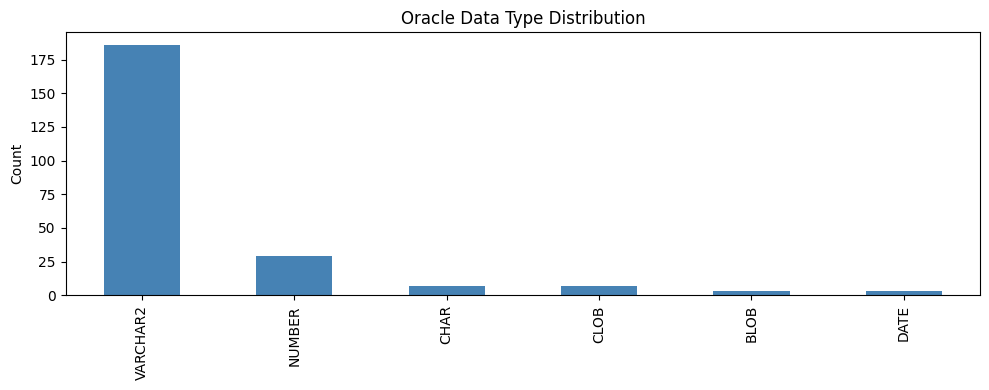

In [4]:
all_types = []
for table in schema.tables:
    for col in table.columns:
        all_types.append(col.data_type or "UNKNOWN")

type_dist = pd.Series(all_types).value_counts()
print("Data type distribution:")
print(type_dist)

fig, ax = plt.subplots(figsize=(10, 4))
type_dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Oracle Data Type Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
constraint_stats = {
    "Primary Keys": sum(1 for t in schema.tables for c in t.columns if c.is_primary_key),
    "Foreign Keys": sum(1 for t in schema.tables for c in t.columns if c.is_foreign_key),
    "Unique": sum(1 for t in schema.tables for c in t.columns if c.is_unique),
    "Indexed": sum(1 for t in schema.tables for c in t.columns if c.is_indexed),
    "Nullable": sum(1 for t in schema.tables for c in t.columns if c.nullable),
}
print("Constraint summary:")
for k, v in constraint_stats.items():
    print(f"  {k}: {v}")

Constraint summary:
  Primary Keys: 0
  Foreign Keys: 0
  Unique: 0
  Indexed: 5
  Nullable: 235


## 3. Text Preprocessing

Column names are transformed into clean, contextualized text for BERT input:
1. Split camelCase / snake_case / UPPER_CASE
2. Expand abbreviations (ID -> identifier, FK -> foreign key, etc.)
3. Remove redundant prefixes (tbl_, col_, fld_)
4. Lowercase and contextualize with table name

In [6]:
preprocessor = TextPreprocessor()

preprocessed_texts = []
column_table_map = []

for table in schema.tables:
    for col in table.columns:
        text = preprocessor.process(col.name, table_name=table.name)
        preprocessed_texts.append(text)
        column_table_map.append(table.name)

print(f"Preprocessed {len(preprocessed_texts)} column names")
print("\nExamples:")
all_cols_flat = [(t.name, c.name) for t in schema.tables for c in t.columns]
for i in range(min(8, len(preprocessed_texts))):
    tname, cname = all_cols_flat[i]
    print(f"  {tname}.{cname} -> \"{preprocessed_texts[i]}\"")

Preprocessed 235 column names

Examples:
  AUDITORIA_LOG.ID -> "auditoria log: identifier"
  AUDITORIA_LOG.TABLA_AFECTADA -> "auditoria log: tabla afectada"
  AUDITORIA_LOG.REGISTRO_ID -> "auditoria log: registro identifier"
  AUDITORIA_LOG.ACCION -> "auditoria log: accion"
  AUDITORIA_LOG.USUARIO -> "auditoria log: usuario"
  AUDITORIA_LOG.FECHA -> "auditoria log: fecha"
  AUDITORIA_LOG.DETALLE -> "auditoria log: detalle"
  BACKUP_DATOS.COL_001 -> "backup datos: 001"


## 4. Structural Encoding

Convert column metadata into numeric vectors:
- **Data types**: One-hot encoding across 12 canonical Oracle types
- **Constraints**: Binary encoding (PK, FK, Unique, Indexed, Nullable)
- **Statistical**: log1p(data_length) to reduce skew

In [7]:
encoder = StructuralEncoder()

all_columns = [col for table in schema.tables for col in table.columns]

e_type = encoder.encode_data_types(all_columns)
e_rest = encoder.encode_constraints(all_columns)
e_stat = encoder.encode_statistical(all_columns)

print(f"Data type encoding (e_type):    {e_type.shape}  -- one-hot over {len(CANONICAL_TYPES)} canonical types")
print(f"Constraint encoding (e_rest):   {e_rest.shape}  -- binary [PK, FK, Unique, Indexed, Nullable]")
print(f"Statistical encoding (e_stat):  {e_stat.shape}  -- log1p(data_length)")

Data type encoding (e_type):    (235, 12)  -- one-hot over 12 canonical types
Constraint encoding (e_rest):   (235, 5)  -- binary [PK, FK, Unique, Indexed, Nullable]
Statistical encoding (e_stat):  (235, 1)  -- log1p(data_length)


Canonical types present:
VARCHAR    186
CHAR         7
NUMBER      29
DATE         3
CLOB         7
BLOB         3
dtype: int64


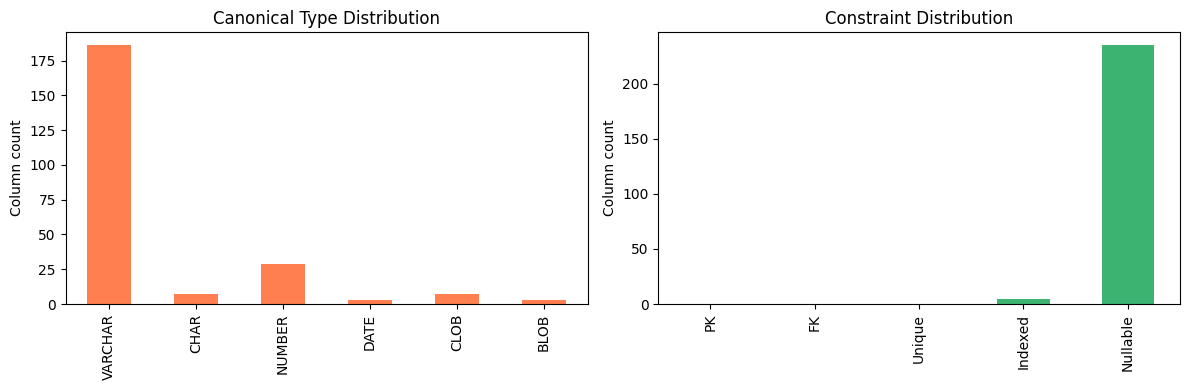

In [8]:
type_sums = e_type.sum(axis=0)
type_presence = pd.Series(type_sums, index=CANONICAL_TYPES).astype(int)
type_presence = type_presence[type_presence > 0]
print("Canonical types present:")
print(type_presence)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
type_presence.plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Canonical Type Distribution")
axes[0].set_ylabel("Column count")

constraint_names = ["PK", "FK", "Unique", "Indexed", "Nullable"]
constraint_sums = e_rest.sum(axis=0).astype(int)
pd.Series(constraint_sums, index=constraint_names).plot(kind="bar", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Constraint Distribution")
axes[1].set_ylabel("Column count")
plt.tight_layout()
plt.show()

## 5. Save Intermediate Data for Notebook 02

In [9]:
import pickle

column_index = [f"{t.name}.{c.name}" for t in schema.tables for c in t.columns]

intermediate = {
    "schema": schema,
    "preprocessed_texts": preprocessed_texts,
    "e_type": e_type,
    "e_rest": e_rest,
    "e_stat": e_stat,
    "all_columns": all_columns,
    "column_index": column_index,
    "column_table_map": column_table_map,
}

output_path = Path.cwd().parent / "output"
output_path.mkdir(exist_ok=True)
save_path = output_path / "intermediate_01.pkl"

with open(save_path, "wb") as f:
    pickle.dump(intermediate, f)

print(f"Saved to {save_path}")
print(f"  schema: {len(schema.tables)} tables, {schema.total_columns()} columns")
print(f"  e_type: {e_type.shape}, e_rest: {e_rest.shape}, e_stat: {e_stat.shape}")

connection.close()

Saved to /Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/output/intermediate_01.pkl
  schema: 22 tables, 235 columns
  e_type: (235, 12), e_rest: (235, 5), e_stat: (235, 1)
